In [11]:
from pathlib import Path
import os
import tempfile
import warnings

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from openpyxl.styles import Alignment, Font, PatternFill
from scipy import stats
from soilgrids import SoilGrids

warnings.filterwarnings('ignore')

BASE_DIR = Path(r"C:\Soilgrids")
DATA_MARTHA_DIR = BASE_DIR / 'datos_martha'
RESULTS_DIR = BASE_DIR / 'resultados'
FIGURES_DIR = BASE_DIR / 'analysis' / 'results_figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SITES_LLAVIUCO_PATH = DATA_MARTHA_DIR / 'sites_Llaviuco_clean.csv'
SITES_YANASACHA_PATH = DATA_MARTHA_DIR / 'sites_Yanasascha_clean.csv'
FIELD_RESULTS_PATH = DATA_MARTHA_DIR / 'results_summary.csv'
SOILGRIDS_WC_PATH = BASE_DIR / 'soilgrids_water_content_bulk_density.csv'
COMBINED_PATH = BASE_DIR / 'combined_field_soilgrids.csv'
FIELD_SAMPLING_SUMMARY_PATH = RESULTS_DIR / 'field_sampling_summary.csv'
FIELD_DESCRIPTIVE_SUMMARY_PATH = RESULTS_DIR / 'field_descriptive_summary.csv'
WILCOXON_RESULTS_PATH = RESULTS_DIR / 'wilcoxon_signed_rank_results.csv'
ERROR_METRICS_PATH = RESULTS_DIR / 'error_metrics_soilgrids_vs_field.csv'
WILCOXON_BY_SITE_PATH = RESULTS_DIR / 'wilcoxon_signed_rank_results_by_site.csv'
ERROR_METRICS_BY_SITE_PATH = RESULTS_DIR / 'error_metrics_soilgrids_vs_field_by_site.csv'
STATISTICS_XLSX_PATH = BASE_DIR / 'soilgrids_vs_field_statistics.xlsx'

PROP_IDS = ['bdod', 'phh2o', 'wv0010', 'wv0033', 'wv1500']
SG_DEPTH_LAYERS = ['0-5cm', '5-15cm', '15-30cm']
FIELD_DEPTH_WEIGHTS = {
    '0_10cm': {'0-5cm': 0.5, '5-15cm': 0.5},
    '10_20cm': {'5-15cm': 0.5, '15-30cm': 0.5},
}
DEPTH_LABEL_MAP = {'0-10': '0_10cm', '10-20': '10_20cm'}
CRS_WGS84 = 'urn:ogc:def:crs:EPSG::4326'

PARAM_PAIRS = [
    ('Bulk density', 'bulk_density_field_g_cm3', 'bdod_sg_g_cm3', 'g/cm3'),
    ('Field capacity', 'vwc_field_cap_field_cm3cm3', 'vwc_fc_sg_cm3cm3', 'cm3/cm3'),
    ('Wilting point', 'vwc_wilt_pt_field_cm3cm3', 'vwc_wp_sg_cm3cm3', 'cm3/cm3'),
    ('Near-saturation (10 kPa)', 'vwc_sat_field_cm3cm3', 'vwc_10kPa_sg_cm3cm3', 'cm3/cm3'),
]

GROUP_ORDER = [
    'Llaviuco_Reference',
    'Llaviuco_Burned',
    'Yanasacha_Reference',
    'Yanasacha_Low_Burn',
    'Yanasacha_High_Burn',
]

GROUP_COLORS = {
    'Llaviuco_Reference': '#2196F3',
    'Llaviuco_Burned': '#F44336',
    'Yanasacha_Low_Burn': '#FF9800',
    'Yanasacha_High_Burn': '#9C27B0',
    'Yanasacha_Reference': '#4CAF50',
}

GROUP_LABELS = {
    'LR': 'Llaviuco Reference',
    'LB': 'Llaviuco Burned',
    'YL': 'Yanasacha Low Burn',
    'YH': 'Yanasacha High Burn',
    'YR': 'Yanasacha Reference',
}
GROUP_SHADES = ['#E3F2FD', '#FFEBEE', '#FFF3E0', '#F3E5F5', '#E8F5E9']


def save_figure(fig, filename, dpi=150):
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches='tight')
    print(f"Saved figure to: {output_path}")
    return output_path


def load_combined():
    return pd.read_csv(COMBINED_PATH)


for service_id, service_name in [('wv0010', '10kPa'), ('wv0033', '33kPa'), ('wv1500', '1500kPa')]:
    SoilGrids.MAP_SERVICES[service_id] = {
        'name': f'Volumetric water content at {service_name}',
        'link': f'https://maps.isric.org/mapserv?map=/map/{service_id}.map',
        'units': 'cm3/dm3 (vol‰)',
    }

sg = SoilGrids()

In [12]:
# Read the site CSV files and combine them for SoilGrids queries
sites_llaviuco = pd.read_csv(SITES_LLAVIUCO_PATH)
sites_yanasacha = pd.read_csv(SITES_YANASACHA_PATH)
all_sites = pd.concat([sites_llaviuco, sites_yanasacha], ignore_index=True)

print(f"Total sites: {len(all_sites)}")
print(f"Llaviuco sites: {len(sites_llaviuco)}")
print(f"Yanasacha sites: {len(sites_yanasacha)}")
print("\nFirst few sites:")
print(all_sites.head())

Total sites: 24
Llaviuco sites: 9
Yanasacha sites: 15

First few sites:
  Reference       Lat        Lon  Elevation        Date  dNBR
0       LR1 -2.806780 -79.159910       3560  25/11/2025   NaN
1       LR2 -2.815830 -79.156100       3685  25/11/2025   NaN
2       LR3 -2.834869 -79.138083       3495  15/01/2026   NaN
3       LR4 -2.832440 -79.142684       3607  15/01/2026   NaN
4       LB1 -2.806710 -79.160220       3585  25/11/2025   0.3


In [13]:
tmpdir = tempfile.mkdtemp()
soilgrids_data = []

for _, row in all_sites.iterrows():
    lat = row['Lat']
    lon = row['Lon']
    site_id = row['Reference']
    offset = 0.001

    try:
        site_data = {'Reference': site_id, 'Lat': lat, 'Lon': lon}
        raw_vals = {prop: {} for prop in PROP_IDS}

        for prop in PROP_IDS:
            for depth_layer in SG_DEPTH_LAYERS:
                coverage_id = f'{prop}_{depth_layer}_mean'
                out_file = Path(tmpdir) / f"{site_id}_{prop}_{depth_layer.replace('-', '_')}.tif"
                try:
                    dataset = sg.get_coverage_data(
                        service_id=prop,
                        coverage_id=coverage_id,
                        crs=CRS_WGS84,
                        west=lon - offset,
                        south=lat - offset,
                        east=lon + offset,
                        north=lat + offset,
                        width=1,
                        height=1,
                        output=str(out_file),
                    )
                    value = float(dataset.values[0, 0, 0])
                    raw_vals[prop][depth_layer] = value if value != -32768 else None
                except Exception as exc:
                    raw_vals[prop][depth_layer] = None
                    print(f"  Warning: {prop} {depth_layer} for {site_id}: {str(exc)[:100]}")

        for field_depth, weights in FIELD_DEPTH_WEIGHTS.items():
            for prop in PROP_IDS:
                layer_values = [raw_vals[prop].get(layer) for layer in weights]
                if all(value is not None for value in layer_values):
                    site_data[f'{prop}_{field_depth}'] = sum(
                        value * weight for value, weight in zip(layer_values, weights.values())
                    )
                else:
                    site_data[f'{prop}_{field_depth}'] = None

        soilgrids_data.append(site_data)
        print(f"Retrieved data for {site_id}")

    except Exception as exc:
        print(f"Error for {site_id}: {exc}")

soilgrids_df = pd.DataFrame(soilgrids_data)
print(f"\nSoilGrids data retrieved for {len(soilgrids_df)} sites")
print(soilgrids_df.head())

Retrieved data for LR1
Retrieved data for LR2
Retrieved data for LR3
Retrieved data for LR4
Retrieved data for LB1
Retrieved data for LB2
Retrieved data for LB3
Retrieved data for LB4
Retrieved data for LB5
Retrieved data for YL1
Retrieved data for YL2
Retrieved data for YL3
Retrieved data for YL4
Retrieved data for YL5
Retrieved data for YH1
Retrieved data for YH2
Retrieved data for YH3
Retrieved data for YH4
Retrieved data for YH5
Retrieved data for YR1
Retrieved data for YR2
Retrieved data for YR3
Retrieved data for YR4
Retrieved data for YR5

SoilGrids data retrieved for 24 sites
  Reference       Lat        Lon  bdod_0_10cm  phh2o_0_10cm  wv0010_0_10cm  \
0       LR1 -2.806780 -79.159910        103.0          53.0          433.0   
1       LR2 -2.815830 -79.156100         99.5          52.0          430.0   
2       LR3 -2.834869 -79.138083        100.5          55.0          431.5   
3       LR4 -2.832440 -79.142684        101.0          54.0          430.0   
4       LB1 -2.8067

In [14]:
# Save the SoilGrids weighted averages for key hydraulic properties
key_props = ['bdod', 'wv0010', 'wv0033', 'wv1500']
wc_cols = ['Reference', 'Lat', 'Lon'] + [
    f'{prop}_{depth}' for prop in key_props for depth in ['0_10cm', '10_20cm']
 ]

soilgrids_wc = soilgrids_df[wc_cols].copy()
soilgrids_wc.to_csv(SOILGRIDS_WC_PATH, index=False)

print(f"Saved {len(soilgrids_wc)} sites (2 depth intervals each) to '{SOILGRIDS_WC_PATH}'")
print(soilgrids_wc.to_string())

Saved 24 sites (2 depth intervals each) to 'C:\Soilgrids\soilgrids_water_content_bulk_density.csv'
   Reference       Lat        Lon  bdod_0_10cm  bdod_10_20cm  wv0010_0_10cm  wv0010_10_20cm  wv0033_0_10cm  wv0033_10_20cm  wv1500_0_10cm  wv1500_10_20cm
0        LR1 -2.806780 -79.159910        103.0         107.5          433.0           413.0          327.0           323.5          172.0           169.0
1        LR2 -2.815830 -79.156100         99.5         104.5          430.0           411.0          346.0           342.5          159.0           156.5
2        LR3 -2.834869 -79.138083        100.5         105.0          431.5           421.5          359.0           358.0          189.5           189.5
3        LR4 -2.832440 -79.142684        101.0         106.0          430.0           415.5          363.0           359.0          174.0           172.5
4        LB1 -2.806710 -79.160220        103.0         107.0          435.0           413.0          325.0           322.5         

In [15]:
# Load field measurements for both depth intervals
field_raw = pd.read_csv(FIELD_RESULTS_PATH, usecols=range(7))
field_raw.columns = [
    'sample_code',
    'organic_matter_pct',
    'pH_field',
    'bulk_density_field_g_cm3',
    'vwc_sat_field_cm3cm3',
    'vwc_field_cap_field_cm3cm3',
    'vwc_wilt_pt_field_cm3cm3',
]
field_raw = field_raw.dropna(subset=['sample_code'])
field_raw['Reference'] = field_raw['sample_code'].str.extract(r'^(\S+)')
field_raw['depth'] = field_raw['sample_code'].str.extract(r'(\d+-\d+)$')

group_map = {
    'LR': 'Llaviuco_Reference',
    'LB': 'Llaviuco_Burned',
    'YL': 'Yanasacha_Low_Burn',
    'YH': 'Yanasacha_High_Burn',
    'YR': 'Yanasacha_Reference',
}
field_raw['group'] = field_raw['Reference'].str[:2].map(group_map)

sg_rows = []
for _, sg_row in soilgrids_df.iterrows():
    for field_depth, sg_suffix in DEPTH_LABEL_MAP.items():
        row_data = {
            'Reference': sg_row['Reference'],
            'Lat': sg_row['Lat'],
            'Lon': sg_row['Lon'],
            'depth': field_depth,
        }
        for prop in PROP_IDS:
            row_data[prop] = sg_row.get(f'{prop}_{sg_suffix}')
        sg_rows.append(row_data)
sg_long = pd.DataFrame(sg_rows)

sg_long['bdod_sg_g_cm3'] = sg_long['bdod'] / 100
sg_long['phh2o_sg'] = sg_long['phh2o'] / 10
sg_long['vwc_10kPa_sg_cm3cm3'] = sg_long['wv0010'] / 1000
sg_long['vwc_fc_sg_cm3cm3'] = sg_long['wv0033'] / 1000
sg_long['vwc_wp_sg_cm3cm3'] = sg_long['wv1500'] / 1000
sg_long = sg_long.drop(columns=PROP_IDS)

field_cols = [
    'Reference',
    'depth',
    'group',
    'organic_matter_pct',
    'pH_field',
    'bulk_density_field_g_cm3',
    'vwc_sat_field_cm3cm3',
    'vwc_field_cap_field_cm3cm3',
    'vwc_wilt_pt_field_cm3cm3',
]

combined = (
    field_raw[field_cols]
    .merge(
        all_sites[['Reference', 'Lat', 'Lon', 'Elevation', 'Date', 'dNBR']],
        on='Reference',
        how='left',
    )
    .merge(sg_long, on=['Reference', 'Lat', 'Lon', 'depth'], how='left')
)

combined.to_csv(COMBINED_PATH, index=False)

print(f"Saved combined dataset to '{COMBINED_PATH}'")
print(f"  {len(combined)} rows ({len(combined) // 2} sites x 2 depths)  |  {combined.shape[1]} columns")
print('\nUnit check — SoilGrids vs field ranges:')
for sg_col, field_col, label in [
    ('bdod_sg_g_cm3', 'bulk_density_field_g_cm3', 'Bulk density (g/cm3)'),
    ('vwc_fc_sg_cm3cm3', 'vwc_field_cap_field_cm3cm3', 'Field capacity (cm3/cm3)'),
    ('vwc_wp_sg_cm3cm3', 'vwc_wilt_pt_field_cm3cm3', 'Wilting point (cm3/cm3)'),
    ('vwc_10kPa_sg_cm3cm3', 'vwc_sat_field_cm3cm3', 'Near-sat / Sat (cm3/cm3)'),
]:
    sg_range = f"{combined[sg_col].min():.3f}-{combined[sg_col].max():.3f}"
    field_range = f"{combined[field_col].min():.3f}-{combined[field_col].max():.3f}"
    print(f"  {label:<35} SG: {sg_range:<15} Field: {field_range}")

Saved combined dataset to 'C:\Soilgrids\combined_field_soilgrids.csv'
  48 rows (24 sites x 2 depths)  |  19 columns

Unit check — SoilGrids vs field ranges:
  Bulk density (g/cm3)                SG: 0.990-1.110     Field: 0.173-0.556
  Field capacity (cm3/cm3)            SG: 0.319-0.388     Field: 0.459-0.704
  Wilting point (cm3/cm3)             SG: 0.151-0.190     Field: 0.181-0.483
  Near-sat / Sat (cm3/cm3)            SG: 0.392-0.435     Field: 0.736-0.957


In [16]:
# Keep only field-measured variables for the introductory summary
if 'combined' not in globals():
    combined = load_combined()

field_vars = [
    'bulk_density_field_g_cm3',
    'vwc_sat_field_cm3cm3',
    'vwc_field_cap_field_cm3cm3',
    'vwc_wilt_pt_field_cm3cm3',
    'organic_matter_pct',
    'pH_field',
]

metric_labels = {
    'bulk_density_field_g_cm3': 'Bulk density (g/cm3)',
    'vwc_sat_field_cm3cm3': 'Vol. water content at saturation (cm3/cm3)',
    'vwc_field_cap_field_cm3cm3': 'Vol. water content at field capacity (cm3/cm3)',
    'vwc_wilt_pt_field_cm3cm3': 'Vol. water content at wilting point (cm3/cm3)',
    'organic_matter_pct': 'Organic matter (%)',
    'pH_field': 'pH',
}

field_df = combined[['Reference', 'group', 'depth'] + field_vars].copy()
field_df = field_df.dropna(subset=['Reference', 'group', 'depth'])
field_df['group'] = pd.Categorical(field_df['group'], categories=GROUP_ORDER, ordered=True)

sample_table = (
    field_df.groupby('group', observed=True)
    .agg(n_sites=('Reference', 'nunique'), n_observations=('Reference', 'size'))
    .reset_index()
    .sort_values('group')
)

long_df = field_df.melt(
    id_vars=['Reference', 'group', 'depth'],
    value_vars=field_vars,
    var_name='metric',
    value_name='value',
).dropna(subset=['value'])

summary_table = (
    long_df.groupby(['group', 'depth', 'metric'], observed=True)['value']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .reset_index()
    .rename(columns={'count': 'n'})
)
summary_table['metric'] = summary_table['metric'].map(metric_labels)
summary_table = summary_table.rename(columns={
    'group': 'site_group',
    'depth': 'depth_cm',
    'metric': 'field_metric',
    'mean': 'mean_value',
    'std': 'std_value',
    'min': 'min_value',
    'max': 'max_value',
})

for col in ['mean_value', 'std_value', 'min_value', 'max_value']:
    summary_table[col] = summary_table[col].round(3)

sample_table.to_csv(FIELD_SAMPLING_SUMMARY_PATH, index=False)
summary_table.to_csv(FIELD_DESCRIPTIVE_SUMMARY_PATH, index=False)

print('Field data summary tables created:')
print(f' - {FIELD_SAMPLING_SUMMARY_PATH}')
print(f' - {FIELD_DESCRIPTIVE_SUMMARY_PATH}')

print('\nSampling coverage by group:')
display(sample_table)

print('\nDescriptive statistics by group, depth, and metric:')
display(summary_table)

Field data summary tables created:
 - C:\Soilgrids\resultados\field_sampling_summary.csv
 - C:\Soilgrids\resultados\field_descriptive_summary.csv

Sampling coverage by group:


,group,n_sites,n_observations
0,Llaviuco_Reference,4,8
1,Llaviuco_Burned,5,10
2,Yanasacha_Reference,5,10
3,Yanasacha_Low_Burn,5,10
4,Yanasacha_High_Burn,5,10



Descriptive statistics by group, depth, and metric:


,site_group,depth_cm,field_metric,n,mean_value,std_value,min_value,max_value
0,Llaviuco_Reference,0-10,Bulk density (g/cm3),4,0.367,0.094,0.265,0.489
1,Llaviuco_Reference,0-10,Organic matter (%),4,46.228,11.666,28.850,53.680
2,Llaviuco_Reference,0-10,pH,4,5.852,0.419,5.360,6.270
3,Llaviuco_Reference,0-10,Vol. water content at field capacity (cm3/cm3),4,0.648,0.025,0.611,0.665
4,Llaviuco_Reference,0-10,Vol. water content at saturation (cm3/cm3),4,0.821,0.028,0.788,0.855
5,Llaviuco_Reference,0-10,Vol. water content at wilting point (cm3/cm3),4,0.334,0.024,0.301,0.359
6,Llaviuco_Reference,10-20,Bulk density (g/cm3),4,0.385,0.114,0.294,0.550
7,Llaviuco_Reference,10-20,Organic matter (%),4,45.688,12.118,27.520,52.170
8,Llaviuco_Reference,10-20,pH,4,5.970,0.559,5.290,6.640
9,Llaviuco_Reference,10-20,Vol. water content at field capacity (cm3/cm3),4,0.669,0.021,0.637,0.680


Saved figure to: C:\Soilgrids\analysis\results_figures\results_vwc_field_vs_soilgrids_linecharts.png


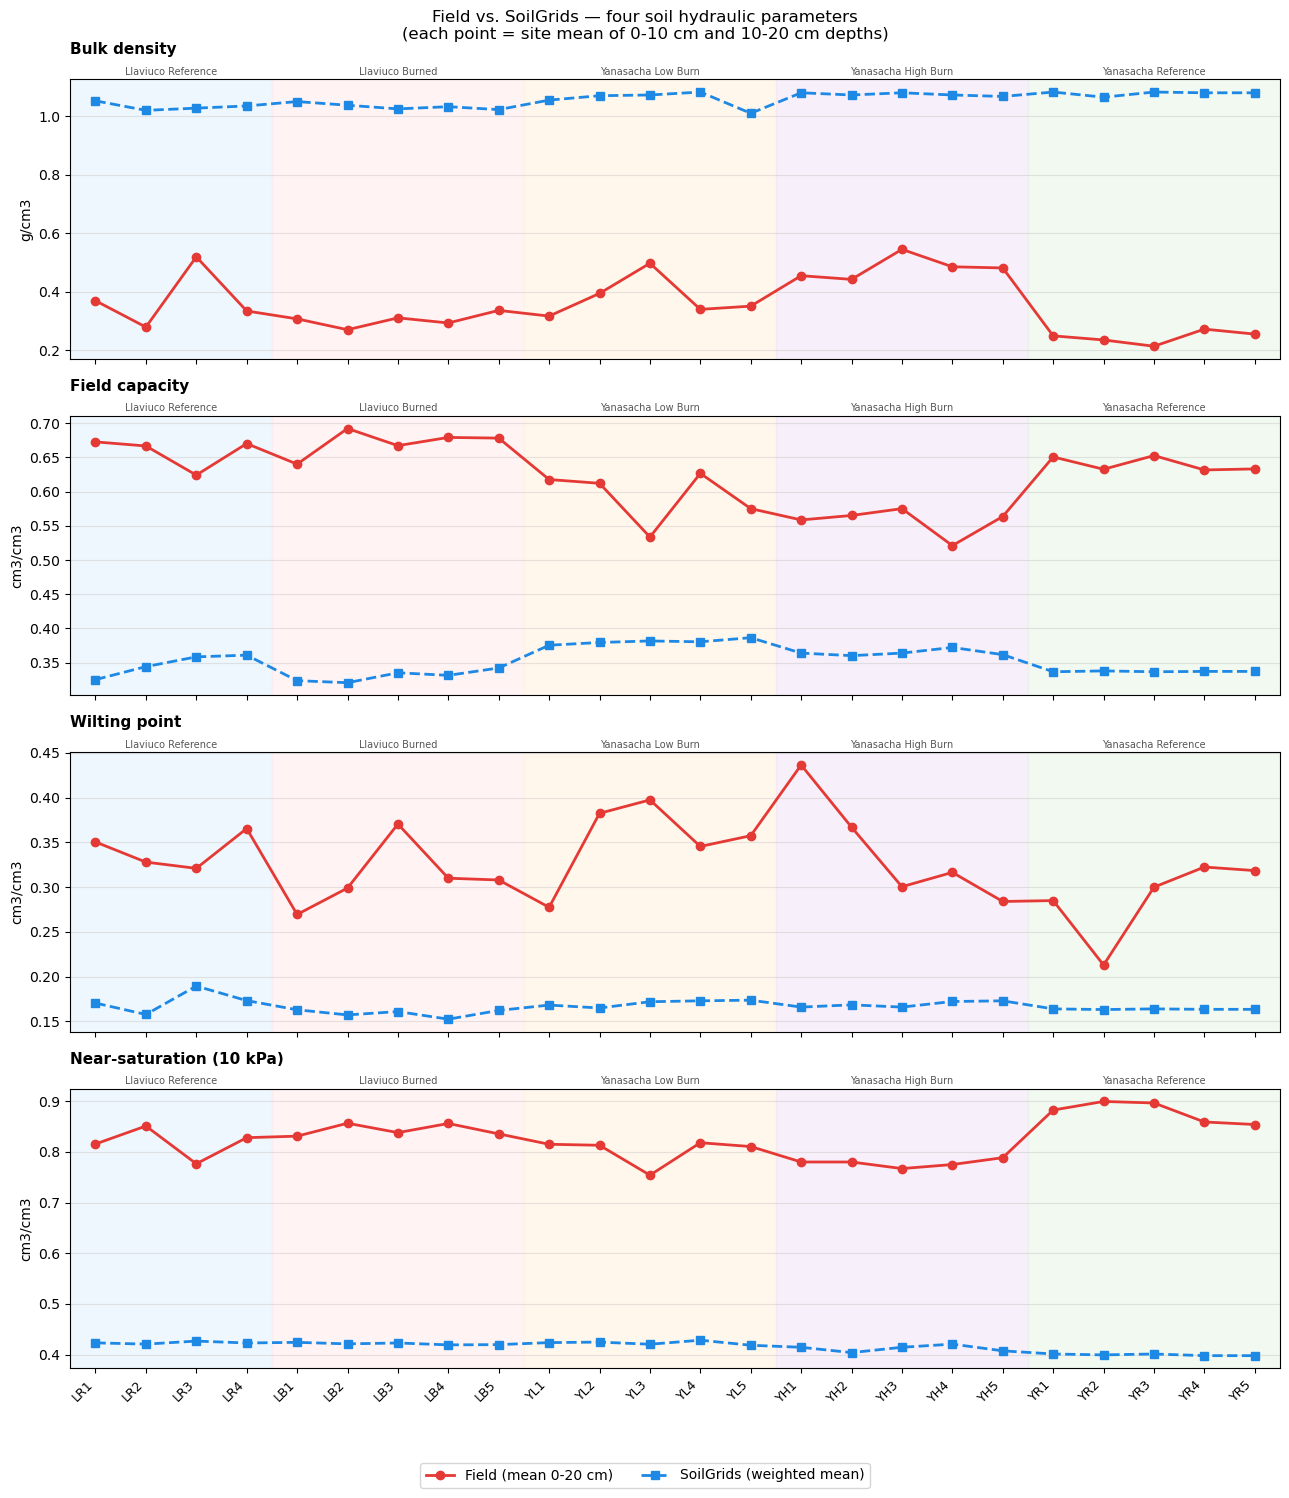

In [17]:
if 'combined' not in globals():
    combined = load_combined()

site_avg = combined.groupby('Reference')[
    [pair[1] for pair in PARAM_PAIRS] + [pair[2] for pair in PARAM_PAIRS]
].mean().reset_index()

prefix_order = {'LR': 0, 'LB': 1, 'YL': 2, 'YH': 3, 'YR': 4}
site_avg['_order'] = (
    site_avg['Reference'].str[:2].map(prefix_order) * 100
    + site_avg['Reference'].str[2:].str.extract(r'(\d+)')[0].astype(float)
 )
site_avg = site_avg.sort_values('_order').drop(columns='_order')
sites = site_avg['Reference'].tolist()
x = range(len(sites))

group_bounds = []
current = site_avg['Reference'].str[:2].iloc[0]
start = 0
for index, ref in enumerate(site_avg['Reference']):
    if ref[:2] != current:
        group_bounds.append((start, index - 1, current))
        current = ref[:2]
        start = index
group_bounds.append((start, len(sites) - 1, current))

fig, axes = plt.subplots(4, 1, figsize=(13, 15), sharex=True)

for ax, (label, field_col, sg_col, unit) in zip(axes, PARAM_PAIRS):
    for (start_idx, end_idx, group_code), shade in zip(group_bounds, GROUP_SHADES):
        ax.axvspan(start_idx - 0.5, end_idx + 0.5, color=shade, alpha=0.6, zorder=0)

    line_field, = ax.plot(
        x,
        site_avg[field_col].values,
        'o-',
        color='#E53935',
        lw=2,
        ms=6,
        label='Field (mean 0-20 cm)',
    )
    line_sg, = ax.plot(
        x,
        site_avg[sg_col].values,
        's--',
        color='#1E88E5',
        lw=2,
        ms=6,
        label='SoilGrids (weighted mean)',
    )

    ax.set_ylabel(unit, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', loc='left', pad=18)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_xlim(-0.5, len(sites) - 0.5)

    transform = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    for start_idx, end_idx, group_code in group_bounds:
        ax.text(
            (start_idx + end_idx) / 2,
            1.01,
            GROUP_LABELS.get(group_code, group_code),
            transform=transform,
            ha='center',
            va='bottom',
            fontsize=7,
            color='#555555',
            clip_on=False,
        )

axes[-1].set_xticks(list(x))
axes[-1].set_xticklabels(sites, rotation=45, ha='right', fontsize=9)

fig.legend(
    handles=[line_field, line_sg],
    labels=['Field (mean 0-20 cm)', 'SoilGrids (weighted mean)'],
    loc='lower center',
    ncol=2,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    'Field vs. SoilGrids — four soil hydraulic parameters\n(each point = site mean of 0-10 cm and 10-20 cm depths)',
    fontsize=12,
 )
plt.tight_layout(rect=[0, 0.04, 1, 1])
save_figure(fig, 'results_vwc_field_vs_soilgrids_linecharts.png')
plt.show()

In [18]:
if 'combined' not in globals():
    combined = load_combined()

print(f"Dataset: {len(combined)} observations  |  {combined['Reference'].nunique()} sites x 2 depths")
print(combined.groupby('group').size().rename('n').to_string())

Dataset: 48 observations  |  24 sites x 2 depths
group
Llaviuco_Burned        10
Llaviuco_Reference      8
Yanasacha_High_Burn    10
Yanasacha_Low_Burn     10
Yanasacha_Reference    10


In [19]:
# Paired Wilcoxon signed-rank test (Field vs SoilGrids)
print('Paired Wilcoxon Signed-Rank Test — Field vs SoilGrids')
print('=' * 68)
print(f"{'Parameter':<32} {'n':>4}  {'W statistic':>12}  {'p-value':>9}  Result")
print('-' * 68)

wilcoxon_rows = []
for label, field_col, sg_col, unit in PARAM_PAIRS:
    df = combined[[field_col, sg_col]].dropna()
    n = len(df)

    if n < 6:
        print(f"  {label}: insufficient data (n={n})")
        wilcoxon_rows.append({
            'Parameter': label,
            'Unit': unit,
            'n': n,
            'W_statistic': None,
            'p_value': None,
            'Result': 'insufficient data',
            'Significance': 'NA',
        })
        continue

    w_stat, p_val = stats.wilcoxon(
        df[field_col].values,
        df[sg_col].values,
        alternative='two-sided',
    )

    sig = '*** p<0.001' if p_val < 0.001 else (
        '**  p<0.01' if p_val < 0.01 else (
            '*   p<0.05' if p_val < 0.05 else f'ns  p={p_val:.3f}'
        )
    )
    print(f"{label:<32} {n:>4}  {w_stat:>12.1f}  {p_val:>9.4f}  {sig}")

    wilcoxon_rows.append({
        'Parameter': label,
        'Unit': unit,
        'n': n,
        'W_statistic': round(float(w_stat), 4),
        'p_value': round(float(p_val), 6),
        'Result': 'significant' if p_val < 0.05 else 'not significant',
        'Significance': sig,
    })

print('=' * 68)
print('W = Wilcoxon test statistic | ns = not significant at alpha=0.05')

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
wilcoxon_df.to_csv(WILCOXON_RESULTS_PATH, index=False)
print(f'Saved Wilcoxon results to: {WILCOXON_RESULTS_PATH}')
display(wilcoxon_df)

Paired Wilcoxon Signed-Rank Test — Field vs SoilGrids
Parameter                           n   W statistic    p-value  Result
--------------------------------------------------------------------
Bulk density                       48           0.0     0.0000  *** p<0.001
Field capacity                     48           0.0     0.0000  *** p<0.001
Wilting point                      47           0.0     0.0000  *** p<0.001
Near-saturation (10 kPa)           48           0.0     0.0000  *** p<0.001
W = Wilcoxon test statistic | ns = not significant at alpha=0.05
Saved Wilcoxon results to: C:\Soilgrids\resultados\wilcoxon_signed_rank_results.csv


,Parameter,Unit,n,W_statistic,p_value,Result,Significance
0,Bulk density,g/cm3,48,0.0,0.0,significant,*** p<0.001
1,Field capacity,cm3/cm3,48,0.0,0.0,significant,*** p<0.001
2,Wilting point,cm3/cm3,47,0.0,0.0,significant,*** p<0.001
3,Near-saturation (10 kPa),cm3/cm3,48,0.0,0.0,significant,*** p<0.001


In [20]:
# Error metrics: Bias, MAE, RMSE
print('Error Metrics — SoilGrids relative to Field')
print('=' * 78)
print(f"{'Parameter':<32} {'Unit':<10} {'n':>4}  {'Bias':>9}  {'MAE':>9}  {'RMSE':>9}  {'rRMSE%':>8}")
print('-' * 78)

metrics_list = []
for label, field_col, sg_col, unit in PARAM_PAIRS:
    df = combined[[field_col, sg_col]].dropna()
    n = len(df)
    if n < 2:
        continue

    error = df[sg_col].values - df[field_col].values
    bias = float(np.mean(error))
    mae = float(np.mean(np.abs(error)))
    rmse = float(np.sqrt(np.mean(error ** 2)))
    rrmse = rmse / np.mean(df[field_col].values) * 100

    metrics_list.append({
        'label': label,
        'unit': unit,
        'n': n,
        'bias': bias,
        'mae': mae,
        'rmse': rmse,
        'rrmse': rrmse,
        'field_col': field_col,
        'sg_col': sg_col,
    })

    sign = '+' if bias >= 0 else ''
    print(f"{label:<32} {unit:<10} {n:>4}  {sign}{bias:>8.4f}  {mae:>9.4f}  {rmse:>9.4f}  {rrmse:>7.1f}%")

print('=' * 78)

metrics_df = pd.DataFrame([
    {
        'Parameter': metric['label'],
        'Unit': metric['unit'],
        'n': metric['n'],
        'Bias': round(metric['bias'], 6),
        'MAE': round(metric['mae'], 6),
        'RMSE': round(metric['rmse'], 6),
        'rRMSE_percent': round(metric['rrmse'], 3),
    }
    for metric in metrics_list
])
metrics_df.to_csv(ERROR_METRICS_PATH, index=False)
print(f'Saved error metrics to: {ERROR_METRICS_PATH}')
display(metrics_df)

Error Metrics — SoilGrids relative to Field
Parameter                        Unit          n       Bias        MAE       RMSE    rRMSE%
------------------------------------------------------------------------------
Bulk density                     g/cm3        48  +  0.6999     0.6999     0.7066    198.1%
Field capacity                   cm3/cm3      48   -0.2701     0.2701     0.2803     45.0%
Wilting point                    cm3/cm3      47   -0.1594     0.1594     0.1693     51.9%
Near-saturation (10 kPa)         cm3/cm3      48   -0.4088     0.4088     0.4115     49.9%
Saved error metrics to: C:\Soilgrids\resultados\error_metrics_soilgrids_vs_field.csv


,Parameter,Unit,n,Bias,MAE,RMSE,rRMSE_percent
0,Bulk density,g/cm3,48,0.699854,0.699854,0.706595,198.146
1,Field capacity,cm3/cm3,48,-0.270083,0.270083,0.280294,45.038
2,Wilting point,cm3/cm3,47,-0.159436,0.159436,0.169312,51.906
3,Near-saturation (10 kPa),cm3/cm3,48,-0.408750,0.408750,0.411496,49.928


In [21]:
# Site-specific paired tests and error metrics
site_masks = {
    'Llaviuco': combined['Reference'].astype(str).str.startswith('L'),
    'Yanasacha': combined['Reference'].astype(str).str.startswith('Y'),
}

wilcoxon_site_rows = []
metrics_site_rows = []

print('Site-Specific Paired Wilcoxon Signed-Rank Test — Field vs SoilGrids')
print('=' * 92)
print(f"{'Site':<12} {'Parameter':<32} {'n':>4}  {'W statistic':>12}  {'p-value':>9}  Result")
print('-' * 92)

for site_name, site_mask in site_masks.items():
    site_df = combined.loc[site_mask].copy()

    for label, field_col, sg_col, unit in PARAM_PAIRS:
        df = site_df[[field_col, sg_col]].dropna()
        n = len(df)

        if n < 6:
            wilcoxon_site_rows.append({
                'Site': site_name,
                'Parameter': label,
                'Unit': unit,
                'n': n,
                'W_statistic': np.nan,
                'p_value': np.nan,
                'Result': 'insufficient data',
                'Significance': 'NA',
            })
            continue

        w_stat, p_val = stats.wilcoxon(
            df[field_col].values,
            df[sg_col].values,
            alternative='two-sided',
        )

        sig = '*** p<0.001' if p_val < 0.001 else (
            '**  p<0.01' if p_val < 0.01 else (
                '*   p<0.05' if p_val < 0.05 else f'ns  p={p_val:.3f}'
            )
        )
        print(f"{site_name:<12} {label:<32} {n:>4}  {w_stat:>12.1f}  {p_val:>9.4f}  {sig}")

        wilcoxon_site_rows.append({
            'Site': site_name,
            'Parameter': label,
            'Unit': unit,
            'n': n,
            'W_statistic': round(float(w_stat), 4),
            'p_value': round(float(p_val), 6),
            'Result': 'significant' if p_val < 0.05 else 'not significant',
            'Significance': sig,
        })

    for label, field_col, sg_col, unit in PARAM_PAIRS:
        df = site_df[[field_col, sg_col]].dropna()
        n = len(df)
        if n < 2:
            continue

        error = df[sg_col].values - df[field_col].values
        bias = float(np.mean(error))
        mae = float(np.mean(np.abs(error)))
        rmse = float(np.sqrt(np.mean(error ** 2)))
        rrmse = rmse / np.mean(df[field_col].values) * 100

        metrics_site_rows.append({
            'Site': site_name,
            'Parameter': label,
            'Unit': unit,
            'n': n,
            'Bias': round(bias, 6),
            'MAE': round(mae, 6),
            'RMSE': round(rmse, 6),
            'rRMSE_percent': round(rrmse, 3),
        })

print('=' * 92)

wilcoxon_site_df = pd.DataFrame(wilcoxon_site_rows)
metrics_site_df = pd.DataFrame(metrics_site_rows)
wilcoxon_site_df.to_csv(WILCOXON_BY_SITE_PATH, index=False)
metrics_site_df.to_csv(ERROR_METRICS_BY_SITE_PATH, index=False)

print(f'Saved Wilcoxon by-site results to: {WILCOXON_BY_SITE_PATH}')
print(f'Saved error metrics by-site results to: {ERROR_METRICS_BY_SITE_PATH}')

print('\nWilcoxon by site:')
display(wilcoxon_site_df)

print('\nError metrics by site:')
display(metrics_site_df)

Site-Specific Paired Wilcoxon Signed-Rank Test — Field vs SoilGrids
Site         Parameter                           n   W statistic    p-value  Result
--------------------------------------------------------------------------------------------
Llaviuco     Bulk density                       18           0.0     0.0000  *** p<0.001
Llaviuco     Field capacity                     18           0.0     0.0002  *** p<0.001
Llaviuco     Wilting point                      18           0.0     0.0000  *** p<0.001
Llaviuco     Near-saturation (10 kPa)           18           0.0     0.0000  *** p<0.001
Yanasacha    Bulk density                       30           0.0     0.0000  *** p<0.001
Yanasacha    Field capacity                     30           0.0     0.0000  *** p<0.001
Yanasacha    Wilting point                      29           0.0     0.0000  *** p<0.001
Yanasacha    Near-saturation (10 kPa)           30           0.0     0.0000  *** p<0.001
Saved Wilcoxon by-site results to: C:\Soilg

,Site,Parameter,Unit,n,W_statistic,p_value,Result,Significance
0,Llaviuco,Bulk density,g/cm3,18,0.0,0.000008,significant,*** p<0.001
1,Llaviuco,Field capacity,cm3/cm3,18,0.0,0.000196,significant,*** p<0.001
2,Llaviuco,Wilting point,cm3/cm3,18,0.0,0.000008,significant,*** p<0.001
3,Llaviuco,Near-saturation (10 kPa),cm3/cm3,18,0.0,0.000008,significant,*** p<0.001
4,Yanasacha,Bulk density,g/cm3,30,0.0,0.000000,significant,*** p<0.001
5,Yanasacha,Field capacity,cm3/cm3,30,0.0,0.000002,significant,*** p<0.001
6,Yanasacha,Wilting point,cm3/cm3,29,0.0,0.000003,significant,*** p<0.001
7,Yanasacha,Near-saturation (10 kPa),cm3/cm3,30,0.0,0.000000,significant,*** p<0.001



Error metrics by site:


,Site,Parameter,Unit,n,Bias,MAE,RMSE,rRMSE_percent
0,Llaviuco,Bulk density,g/cm3,18,0.697833,0.697833,0.701767,208.997
1,Llaviuco,Field capacity,cm3/cm3,18,-0.327389,0.327389,0.329025,49.444
2,Llaviuco,Wilting point,cm3/cm3,18,-0.159444,0.159444,0.164331,50.615
3,Llaviuco,Near-saturation (10 kPa),cm3/cm3,18,-0.409889,0.409889,0.410789,49.374
4,Yanasacha,Bulk density,g/cm3,30,0.701067,0.701067,0.709477,192.218
5,Yanasacha,Field capacity,cm3/cm3,30,-0.235700,0.235700,0.246473,41.320
6,Yanasacha,Wilting point,cm3/cm3,29,-0.159431,0.159431,0.172331,52.678
7,Yanasacha,Near-saturation (10 kPa),cm3/cm3,30,-0.408067,0.408067,0.411920,50.265


## Summary: Site-Specific Wilcoxon Tests and Error Metrics

### Paired Wilcoxon signed-rank test (Field vs SoilGrids)

The paired signed-rank test was run separately for each site group (site x depth matched pairs).

- **Llaviuco (n = 18 per parameter):** all four parameters were significant (**p < 0.001**).
- **Yanasacha (n = 30 per parameter):** all four parameters were significant (**p < 0.001**).

This indicates that, within both sites, SoilGrids values differ systematically from field observations for bulk density, field capacity, wilting point, and near-saturation water content.

### Error metrics by site (SoilGrids - Field)

#### Llaviuco

- **Bulk density:** Bias = **+0.6978** g/cm3, RMSE = **0.7018**, rRMSE = **209.0%**
- **Field capacity:** Bias = **-0.3274** cm3/cm3, RMSE = **0.3290**, rRMSE = **49.4%**
- **Wilting point:** Bias = **-0.1594** cm3/cm3, RMSE = **0.1643**, rRMSE = **50.6%**
- **Near-saturation (10 kPa):** Bias = **-0.4099** cm3/cm3, RMSE = **0.4108**, rRMSE = **49.4%**

#### Yanasacha

- **Bulk density:** Bias = **+0.7011** g/cm3, RMSE = **0.7095**, rRMSE = **192.2%**
- **Field capacity:** Bias = **-0.2357** cm3/cm3, RMSE = **0.2465**, rRMSE = **41.3%**
- **Wilting point:** Bias = **-0.1592** cm3/cm3, RMSE = **0.1717**, rRMSE = **52.5%**
- **Near-saturation (10 kPa):** Bias = **-0.4081** cm3/cm3, RMSE = **0.4119**, rRMSE = **50.3%**

### Interpretation

- SoilGrids shows a **consistent positive bias** for bulk density in both sites (strong overestimation).
- SoilGrids shows **consistent negative bias** for water-content parameters in both sites (systematic underestimation).
- Relative error is very high for bulk density at both sites, and around 40-53% for hydraulic water-content parameters.
- Compared between sites, Yanasacha has slightly lower relative error for field capacity, while both sites show similar error magnitude for wilting point and near-saturation.

Saved figure to: C:\Soilgrids\analysis\results_figures\results_vwc_scatter_field_vs_soilgrids.png


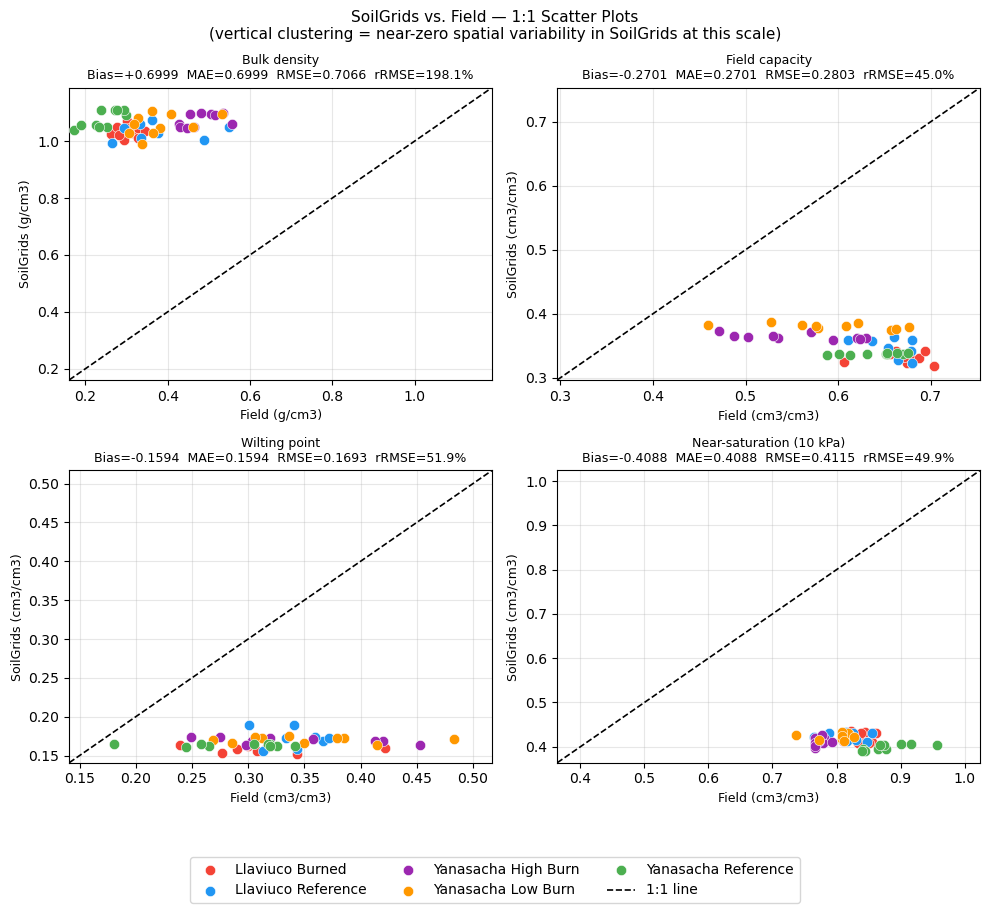

In [22]:
# Scatter plots with 1:1 line
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_list):
    df_plot = combined[[metric['field_col'], metric['sg_col'], 'group']].dropna()

    for group_name, group_df in df_plot.groupby('group'):
        ax.scatter(
            group_df[metric['field_col']],
            group_df[metric['sg_col']],
            label=group_name.replace('_', ' '),
            color=GROUP_COLORS.get(group_name, 'grey'),
            s=55,
            edgecolors='white',
            linewidths=0.4,
            zorder=3,
        )

    all_values = pd.concat([df_plot[metric['field_col']], df_plot[metric['sg_col']]])
    limits = [all_values.min() * 0.93, all_values.max() * 1.07]
    ax.plot(limits, limits, 'k--', lw=1.2, label='1:1 line', zorder=2)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_xlabel(f"Field ({metric['unit']})", fontsize=9)
    ax.set_ylabel(f"SoilGrids ({metric['unit']})", fontsize=9)

    sign = '+' if metric['bias'] >= 0 else ''
    ax.set_title(
        f"{metric['label']}\n"
        f"Bias={sign}{metric['bias']:.4f}  MAE={metric['mae']:.4f}  RMSE={metric['rmse']:.4f}  rRMSE={metric['rrmse']:.1f}%",
        fontsize=9,
    )
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    fontsize=10,
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.02),
    frameon=True,
 )

fig.suptitle(
    'SoilGrids vs. Field — 1:1 Scatter Plots\n(vertical clustering = near-zero spatial variability in SoilGrids at this scale)',
    fontsize=11,
 )
plt.tight_layout(rect=[0, 0.08, 1, 1])
save_figure(fig, 'results_vwc_scatter_field_vs_soilgrids.png')
plt.show()

In [23]:
# Kruskal-Wallis test: |error| across burn categories
print('Kruskal-Wallis Test — |SoilGrids error| by burn group')
print('=' * 68)
print(f"{'Parameter':<32} {'H statistic':>12}  {'p-value':>9}  Result")
print('-' * 68)

for label, field_col, sg_col, unit in PARAM_PAIRS:
    df = combined[[field_col, sg_col, 'group']].dropna().copy()
    df['abs_error'] = np.abs(df[sg_col] - df[field_col])
    group_samples = [group['abs_error'].values for _, group in df.groupby('group') if len(group) >= 3]

    if len(group_samples) < 2:
        print(f"{label:<32} {'—':>12}  {'—':>9}  insufficient groups")
        continue

    h_stat, p_val = stats.kruskal(*group_samples)
    sig = '*** p<0.001' if p_val < 0.001 else (
        '**  p<0.01' if p_val < 0.01 else (
            '*   p<0.05' if p_val < 0.05 else f'ns  p={p_val:.3f}'
        )
    )
    print(f"{label:<32} {h_stat:>12.3f}  {p_val:>9.4f}  {sig}")

print('=' * 68)
print('H = Kruskal-Wallis statistic  |  ns = not significant at alpha=0.05')
print('\nObservations per group:')
print(combined.groupby('group').size().rename('n').to_string())

Kruskal-Wallis Test — |SoilGrids error| by burn group
Parameter                         H statistic    p-value  Result
--------------------------------------------------------------------
Bulk density                           33.539     0.0000  *** p<0.001
Field capacity                         31.910     0.0000  *** p<0.001
Wilting point                           4.672     0.3226  ns  p=0.323
Near-saturation (10 kPa)               35.117     0.0000  *** p<0.001
H = Kruskal-Wallis statistic  |  ns = not significant at alpha=0.05

Observations per group:
group
Llaviuco_Burned        10
Llaviuco_Reference      8
Yanasacha_High_Burn    10
Yanasacha_Low_Burn     10
Yanasacha_Reference    10


In [24]:
# Export Wilcoxon and error metrics to Excel
rows = []
for label, field_col, sg_col, unit in PARAM_PAIRS:
    df = combined[[field_col, sg_col]].dropna()
    n = len(df)

    if n >= 6:
        w_stat, p_wilcox = stats.wilcoxon(
            df[field_col].values,
            df[sg_col].values,
            alternative='two-sided',
        )
        if p_wilcox < 0.001:
            sig = '***'
        elif p_wilcox < 0.01:
            sig = '**'
        elif p_wilcox < 0.05:
            sig = '*'
        else:
            sig = 'ns'
    else:
        w_stat = None
        p_wilcox = None
        sig = None

    error = df[sg_col].values - df[field_col].values
    bias = float(np.mean(error))
    mae = float(np.mean(np.abs(error)))
    rmse = float(np.sqrt(np.mean(error ** 2)))
    rrmse = rmse / np.mean(df[field_col].values) * 100

    rows.append({
        'Parameter': label,
        'Unit': unit,
        'n': n,
        'Bias (SG-Field)': round(bias, 5),
        'MAE': round(mae, 5),
        'RMSE': round(rmse, 5),
        'rRMSE (%)': round(rrmse, 2),
        'Wilcoxon W': round(w_stat, 1) if w_stat is not None else None,
        'p-value (Wilcoxon)': round(p_wilcox, 5) if p_wilcox is not None else None,
        'Significance': sig,
    })

results_df = pd.DataFrame(rows)
with pd.ExcelWriter(STATISTICS_XLSX_PATH, engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='Statistics', index=False)
    worksheet = writer.sheets['Statistics']

    for column in worksheet.columns:
        max_len = max(len(str(cell.value)) if cell.value is not None else 0 for cell in column)
        worksheet.column_dimensions[column[0].column_letter].width = max_len + 3

    header_fill = PatternFill(start_color='1E88E5', end_color='1E88E5', fill_type='solid')
    for cell in worksheet[1]:
        cell.font = Font(bold=True, color='FFFFFF')
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal='center')

    sig_fill = PatternFill(start_color='FFF9C4', end_color='FFF9C4', fill_type='solid')
    for row in worksheet.iter_rows(min_row=2, max_row=worksheet.max_row):
        sig_val = row[9].value
        if sig_val in ('*', '**', '***'):
            for cell in row:
                cell.fill = sig_fill

print(f"Saved statistics to '{STATISTICS_XLSX_PATH}'")
print(results_df.to_string(index=False))

Saved statistics to 'C:\Soilgrids\soilgrids_vs_field_statistics.xlsx'
               Parameter    Unit  n  Bias (SG-Field)     MAE    RMSE  rRMSE (%)  Wilcoxon W  p-value (Wilcoxon) Significance
            Bulk density   g/cm3 48          0.69985 0.69985 0.70660     198.15         0.0                 0.0          ***
          Field capacity cm3/cm3 48         -0.27008 0.27008 0.28029      45.04         0.0                 0.0          ***
           Wilting point cm3/cm3 47         -0.15944 0.15944 0.16931      51.91         0.0                 0.0          ***
Near-saturation (10 kPa) cm3/cm3 48         -0.40875 0.40875 0.41150      49.93         0.0                 0.0          ***


In [25]:
# Initial field data summary
if 'combined' not in globals():
    combined = load_combined()

site_df = (
    combined[['Reference', 'Lat', 'Lon', 'Date', 'group']]
    .dropna(subset=['Reference', 'Lat', 'Lon'])
    .drop_duplicates(subset=['Reference'])
    .copy()
 )
obs_df = combined[['Reference', 'depth', 'group']].dropna(subset=['Reference', 'depth']).copy()

site_df['Date_parsed'] = pd.to_datetime(site_df.get('Date'), errors='coerce')
valid_dates = site_df['Date_parsed'].dropna()
if len(valid_dates) > 0:
    date_start = valid_dates.min().strftime('%Y-%m-%d')
    date_end = valid_dates.max().strftime('%Y-%m-%d')
    n_sampling_dates = valid_dates.dt.date.nunique()
    date_text = f'{date_start} to {date_end} ({n_sampling_dates} sampling date(s))'
else:
    date_text = 'Date metadata not available in the loaded table'

n_sites = site_df['Reference'].nunique()
n_observations = len(obs_df)

burn_mask_sites = site_df['group'].fillna('').str.contains('Burn', case=False)
burned_sites = int(burn_mask_sites.sum())
unburned_sites = int(n_sites - burned_sites)
burn_mask_obs = obs_df['group'].fillna('').str.contains('Burn', case=False)
burned_obs = int(burn_mask_obs.sum())
unburned_obs = int(n_observations - burned_obs)

depth_values = sorted(obs_df['depth'].dropna().astype(str).unique().tolist())
depth_text = ', '.join(depth_values) if depth_values else 'Depth metadata not available'

measured_parameters = [
    'Soil organic matter (%)',
    'pH',
    'Bulk density (g/cm3)',
    'Volumetric water content at saturation (cm3/cm3)',
    'Volumetric water content at field capacity (cm3/cm3)',
    'Volumetric water content at wilting point (cm3/cm3)',
]
params_text = '; '.join(measured_parameters)

lat_min = site_df['Lat'].min()
lat_max = site_df['Lat'].max()
lon_min = site_df['Lon'].min()
lon_max = site_df['Lon'].max()

summary_md = f"""
### Initial Field Data Summary

The field campaign includes **{n_sites} sites** and **{n_observations} total samples (site x depth observations)**.

- **Sampling dates:** {date_text}
- **Burned vs unburned sites:** {burned_sites} burned and {unburned_sites} unburned
- **Burned vs unburned samples:** {burned_obs} burned-associated and {unburned_obs} unburned-associated observations
- **Sampling depth intervals:** {depth_text}
- **Measured field parameters:** {params_text}
- **Coordinate bounding box (WGS84):**
  - Latitude: {lat_min:.5f} to {lat_max:.5f}
  - Longitude: {lon_min:.5f} to {lon_max:.5f}

Overall, the dataset captures both burned and reference conditions across two depth intervals, supporting an initial comparison of field-measured soil hydraulic properties with SoilGrids estimates.
"""

display(Markdown(summary_md))

quick_stats = pd.DataFrame({
    'metric': [
        'Number of sites',
        'Number of observations',
        'Burned sites',
        'Unburned sites',
        'Burned observations',
        'Unburned observations',
        'Depth intervals',
        'Measured field parameters',
        'Latitude min',
        'Latitude max',
        'Longitude min',
        'Longitude max',
    ],
    'value': [
        n_sites,
        n_observations,
        burned_sites,
        unburned_sites,
        burned_obs,
        unburned_obs,
        depth_text,
        params_text,
        round(float(lat_min), 5),
        round(float(lat_max), 5),
        round(float(lon_min), 5),
        round(float(lon_max), 5),
    ],
})

print('Quick summary table:')
display(quick_stats)


### Initial Field Data Summary

The field campaign includes **24 sites** and **48 total samples (site x depth observations)**.

- **Sampling dates:** 2025-11-25 to 2026-03-07 (5 sampling date(s))
- **Burned vs unburned sites:** 15 burned and 9 unburned
- **Burned vs unburned samples:** 30 burned-associated and 18 unburned-associated observations
- **Sampling depth intervals:** 0-10, 10-20
- **Measured field parameters:** Soil organic matter (%); pH; Bulk density (g/cm3); Volumetric water content at saturation (cm3/cm3); Volumetric water content at field capacity (cm3/cm3); Volumetric water content at wilting point (cm3/cm3)
- **Coordinate bounding box (WGS84):**
  - Latitude: -2.97085 to -2.80671
  - Longitude: -79.20765 to -79.13808

Overall, the dataset captures both burned and reference conditions across two depth intervals, supporting an initial comparison of field-measured soil hydraulic properties with SoilGrids estimates.


Quick summary table:


,metric,value
0,Number of sites,24
1,Number of observations,48
2,Burned sites,15
3,Unburned sites,9
4,Burned observations,30
5,Unburned observations,18
6,Depth intervals,"0-10, 10-20"
7,Measured field parameters,Soil organic matter (%); pH; Bulk density (g/c...
8,Latitude min,-2.97085
9,Latitude max,-2.80671
